# Distillation Results — v7

This notebook loads the evaluated distillation combinations:
3 teachers × 4 students × 3 conditions.

Local JSONL files are the primary source of truth. Runtime and throughput statistics are pulled from the matching WandB run summaries when present, and the notebook falls back to the WandB API only if a local summary is missing.


In [1]:
from __future__ import annotations

import json
import re
from functools import lru_cache
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

try:
    import wandb
except ImportError:
    wandb = None

plt.rcParams["figure.dpi"] = 120
pd.set_option("display.max_columns", 50)
pd.set_option("display.max_colwidth", 120)

PROJECT_ROOT = Path("../../").resolve()
RESULTS_ROOT = PROJECT_ROOT / "data/safety_experiment/distillation"
WANDB_ROOT = PROJECT_ROOT / "logs/wandb/wandb"
VAL_F1_CACHE_PATH = PROJECT_ROOT / "data" / "cache" / "val_harm_f1_index.json"
WANDB_ENTITY = "Jazhyc"
WANDB_PROJECT = "Distillation Results"

TEACHERS = {
    "cyankiwi-Mistral-Small-4-119B-2603-AWQ-4bit": "Mistral Small 4 119B",
    "cyankiwi-Qwen3.5-122B-A10B-AWQ-4bit": "Qwen 3.5 122B",
    "openai-gpt-oss-120b": "GPT-OSS 120B",
    "RedHatAI-gemma-3-27b-it-quantized.w4a16": "Gemma 3 27B",
}

STUDENTS = {
    "gemma-3-12b": "Gemma 3 12B",
    "llama-3.1-8b": "Llama 3.1 8B",
    "ministral-3-14b-reasoning": "Ministral 3 14B",
    "qwen3.5-9b": "Qwen3.5 9B",
}

CONDITIONS = {
    "no_intent": "No Intent",
    "synthetic_intent": "Synthetic Intent",
    "human_intent": "Human Intent",
}

DATASETS = {
    "aegis": "Aegis",
    "annotated-intents": "Annotated Intents",
    "toxic-chat": "Toxic Chat",
    "wildguardmix": "WildGuardMix",
    "xstest": "XSTest",
}

# Distillation eval runs log metrics under eval-condition keys, not training-condition slugs.
EVAL_SUFFIX = {
    "no_intent": "finetuned_reasoning_classification",
    "synthetic_intent": "finetuned_reasoning_synthetic_intent",
    "human_intent": "finetuned_reasoning_human_intent",
}

TEACHER_ORDER = list(TEACHERS.keys())
STUDENT_ORDER = list(STUDENTS.keys())
CONDITION_ORDER = list(CONDITIONS.keys())
DATASET_ORDER = list(DATASETS.keys())


def _to_binary_label(value):
    if value is None:
        return None
    if isinstance(value, bool):
        return 1 if value else 0
    if isinstance(value, (int, float)):
        return int(value)

    text = str(value).strip().lower()
    if text in {"harmful", "unsafe", "1", "true", "yes"}:
        return 1
    if text in {"safe", "benign", "0", "false", "no"}:
        return 0
    return None


def find_jsonl_file(dataset_dir: Path) -> Path | None:
    if not dataset_dir.exists():
        return None

    preferred = sorted(dataset_dir.glob("*_classification.jsonl"))
    if preferred:
        return preferred[0]

    any_jsonl = sorted(dataset_dir.glob("*.jsonl"))
    if any_jsonl:
        return any_jsonl[0]

    return None


def compute_binary_metrics(jsonl_path: Path) -> dict:
    y_true = []
    y_pred = []
    missing_predictions = 0
    num_rows = 0

    with open(jsonl_path) as handle:
        for line in handle:
            line = line.strip()
            if not line:
                continue
            num_rows += 1
            record = json.loads(line)

            true_value = (
                record.get("true_harm_binary")
                if record.get("true_harm_binary") is not None
                else record.get("true_harm")
            )
            pred_value = (
                record.get("predicted_harm")
                if record.get("predicted_harm") is not None
                else record.get("pred_harm")
            )

            y_t = _to_binary_label(true_value)
            y_p = _to_binary_label(pred_value)

            if y_t is None or y_p is None:
                missing_predictions += 1
                continue

            y_true.append(y_t)
            y_pred.append(y_p)

    num_scored = len(y_true)
    if num_scored == 0:
        return {
            "num_rows": num_rows,
            "num_scored": 0,
            "missing_predictions": missing_predictions,
            "accuracy": 0.0,
            "precision": 0.0,
            "recall": 0.0,
            "f1": 0.0,
        }

    return {
        "num_rows": num_rows,
        "num_scored": num_scored,
        "missing_predictions": missing_predictions,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
    }


def _extract_run_name_from_config(config_path: Path) -> str | None:
    try:
        with open(config_path) as handle:
            for raw_line in handle:
                line = raw_line.strip()
                if line.startswith("run_name:"):
                    return line.split(":", 1)[1].strip().strip("\"'")
    except Exception:
        return None
    return None


def _run_name_from_api_run(run) -> str | None:
    cfg = run.config or {}
    candidates = [
        cfg.get("run_name"),
        cfg.get("wandb.run_name"),
        cfg.get("wandb", {}).get("run_name") if isinstance(cfg.get("wandb"), dict) else None,
        getattr(run, "display_name", None),
        getattr(run, "name", None),
    ]
    for candidate in candidates:
        if isinstance(candidate, str) and candidate.startswith("distill--"):
            return candidate
    return None


@lru_cache(maxsize=1)
def _api_summary_index() -> dict[str, dict]:
    index: dict[str, dict] = {}
    if wandb is None:
        return index

    api = wandb.Api()
    runs = api.runs(path=f"{WANDB_ENTITY}/{WANDB_PROJECT}")
    for run in runs:
        run_name = _run_name_from_api_run(run)
        if not run_name:
            continue
        summary = dict(run.summary)
        summary["_source"] = "api"
        summary["_wandb_run_id"] = run.id
        summary["_wandb_run_name"] = run_name
        index[run_name] = summary
    return index


@lru_cache(maxsize=1)
def _local_summary_index() -> dict[str, dict]:
    index: dict[str, dict] = {}
    if not WANDB_ROOT.exists():
        return index

    for summary_path in WANDB_ROOT.glob("run-*/files/wandb-summary.json"):
        run_files_dir = summary_path.parent
        config_path = run_files_dir / "config.yaml"
        run_name = _extract_run_name_from_config(config_path)
        if not run_name:
            continue
        try:
            with open(summary_path) as handle:
                payload = json.load(handle)
            payload["_source"] = "local"
            payload["_local_summary_path"] = str(summary_path)
            index[run_name] = payload
        except Exception:
            continue
    return index


@lru_cache(maxsize=None)
def load_run_summary(run_name: str) -> dict:
    try:
        api_summary = _api_summary_index().get(run_name)
        if api_summary is not None:
            return api_summary
    except Exception:
        pass

    local_payload = _local_summary_index().get(run_name)
    if local_payload is not None:
        return local_payload

    return {"_source": "missing"}


def summary_stat(summary: dict, key: str):
    value = summary.get(key)
    if value is not None:
        return value
    if key == "runtime" and summary.get("_runtime") is not None:
        return summary.get("_runtime")
    wandb_meta = summary.get("_wandb")
    if isinstance(wandb_meta, dict):
        return wandb_meta.get(key)
    return None



@lru_cache(maxsize=1)
def _val_harm_f1_index() -> dict[tuple[str, str, str], float]:
    """
    For each (teacher_slug, student_slug, condition_slug) combination, return the
    best val_harm_f1 from the corresponding distillation sweep W&B training project.
    Mirrors the adapter-selection logic in submit_distillation_eval.py.

    Results are cached to VAL_F1_CACHE_PATH so subsequent notebook runs are
    instant. Set REFRESH_VAL_F1_CACHE = True in the execution cell to re-fetch.
    """
    # File cache hit
    if VAL_F1_CACHE_PATH.exists():
        try:
            with open(VAL_F1_CACHE_PATH) as fh:
                raw = json.load(fh)
            return {tuple(k.split("|")): v for k, v in raw.items()}
        except Exception:
            pass

    # Query W&B
    index: dict[tuple[str, str, str], float] = {}
    if wandb is None:
        return index

    api = wandb.Api()
    for teacher_slug in TEACHERS:
        for student_slug in STUDENTS:
            project = f"distillation-sweep-{student_slug}--{teacher_slug}"
            try:
                runs = api.runs(path=f"{WANDB_ENTITY}/{project}", filters={"state": "finished"})
            except Exception:
                continue

            for run in runs:
                run_condition = (
                    run.summary.get("reasoning_traces_condition")
                    or run.config.get("data", {}).get("reasoning_traces_condition")
                )
                if run_condition not in CONDITIONS:
                    continue

                f1 = run.summary.get("val_harm_f1")
                if f1 is None:
                    continue

                key = (teacher_slug, student_slug, run_condition)
                if key not in index or f1 > index[key]:
                    index[key] = float(f1)

    # Persist to file cache
    try:
        VAL_F1_CACHE_PATH.parent.mkdir(parents=True, exist_ok=True)
        with open(VAL_F1_CACHE_PATH, "w") as fh:
            json.dump({"|".join(k): v for k, v in index.items()}, fh, indent=2)
    except Exception:
        pass

    return index

def load_combo_rows() -> tuple[pd.DataFrame, list[str]]:
    rows = []
    missing = []

    for teacher_slug, teacher_name in TEACHERS.items():
        for student_slug, student_name in STUDENTS.items():
            for condition_slug, condition_name in CONDITIONS.items():
                combo_dir = RESULTS_ROOT / teacher_slug / student_slug / condition_slug
                run_name = f"distill--{teacher_slug}--{student_slug}--{condition_slug}"
                summary = load_run_summary(run_name)
                val_harm_f1 = _val_harm_f1_index().get((teacher_slug, student_slug, condition_slug))

                if not combo_dir.exists():
                    missing.append(f"{teacher_slug}/{student_slug}/{condition_slug}: missing combo directory")
                    continue

                for dataset_slug, dataset_name in DATASETS.items():
                    dataset_dir = combo_dir / dataset_slug
                    jsonl_path = find_jsonl_file(dataset_dir)
                    if jsonl_path is None:
                        missing.append(f"{teacher_slug}/{student_slug}/{condition_slug}/{dataset_slug}: missing JSONL")
                        continue

                    metrics = compute_binary_metrics(jsonl_path)
                    eval_suffix = EVAL_SUFFIX[condition_slug]
                    prefix = f"{dataset_slug}/{eval_suffix}"
                    wandb_elapsed_s = summary.get(f"{prefix}/elapsed_s")
                    wandb_total_tokens = summary.get(f"{prefix}/total_tokens")
                    wandb_tokens_per_second = summary.get(f"{prefix}/tokens_per_second")

                    rows.append(
                        {
                            "teacher_slug": teacher_slug,
                            "teacher": teacher_name,
                            "student_slug": student_slug,
                            "student": student_name,
                            "condition_slug": condition_slug,
                            "condition": condition_name,
                            "dataset_slug": dataset_slug,
                            "dataset": dataset_name,
                            "run_name": run_name,
                            "jsonl_path": str(jsonl_path.relative_to(PROJECT_ROOT)),
                            "wandb_source": summary.get("_source", "missing"),
                            "wandb_runtime_s": summary_stat(summary, "runtime"),
                            "wandb_elapsed_s": wandb_elapsed_s,
                            "wandb_total_tokens": wandb_total_tokens,
                            "wandb_tokens_per_second": wandb_tokens_per_second,
                            "val_harm_f1": val_harm_f1,
                            **metrics,
                        }
                    )

    return pd.DataFrame(rows), missing

Loaded 32/32 combinations and 160/160 dataset files.
WandB source counts: {'api': 32}


,teacher,student,condition,datasets_loaded,accuracy,precision,recall,f1,tokens,elapsed_s,tok_per_s,wandb_runtime_s,wandb_source
17,Kimi K2.5,Gemma 3 12B,Without Intent,5,0.833,0.714,0.842,0.768,2094540,534.9,3915.9,610,api
16,Kimi K2.5,Gemma 3 12B,With Intent,5,0.845,0.736,0.849,0.784,2366231,654.9,3612.9,726,api
19,Kimi K2.5,Llama 3.1 8B,Without Intent,5,0.814,0.696,0.809,0.743,2167736,306.6,7071.3,358,api
18,Kimi K2.5,Llama 3.1 8B,With Intent,5,0.825,0.759,0.720,0.736,2602597,440.1,5913.4,492,api
21,Kimi K2.5,Ministral 8B,Without Intent,5,0.823,0.693,0.863,0.763,2235789,410.7,5444.1,460,api
20,Kimi K2.5,Ministral 8B,With Intent,5,0.842,0.773,0.775,0.773,2481060,500.4,4958.1,562,api
23,Kimi K2.5,Qwen3 8B,Without Intent,5,0.830,0.752,0.772,0.761,2234882,343.2,6512.4,401,api
22,Kimi K2.5,Qwen3 8B,With Intent,5,0.834,0.747,0.798,0.769,2245379,389.0,5771.9,444,api
25,GPT-OSS 120B,Gemma 3 12B,Without Intent,5,0.860,0.760,0.873,0.810,1207679,322.1,3749.4,375,api
24,GPT-OSS 120B,Gemma 3 12B,With Intent,5,0.852,0.765,0.847,0.801,1378242,402.1,3427.7,457,api



Dataset-level details (first 12 rows):


,teacher,student,condition,dataset,accuracy,precision,recall,f1,num_rows,missing_predictions,wandb_elapsed_s,wandb_total_tokens,wandb_tokens_per_second
0,Kimi K2.5,Gemma 3 12B,Without Intent,Aegis,0.768,0.759,0.835,0.795,1964,0,112.2,435577,3883.1
1,Kimi K2.5,Gemma 3 12B,Without Intent,Annotated Intents,0.694,0.667,0.738,0.701,173,0,22.0,44061,2004.8
2,Kimi K2.5,Gemma 3 12B,Without Intent,Toxic Chat,0.919,0.458,0.776,0.576,5083,0,259.7,1119515,4311.1
3,Kimi K2.5,Gemma 3 12B,Without Intent,WildGuardMix,0.867,0.832,0.877,0.854,1699,0,115.9,403587,3481.7
4,Kimi K2.5,Gemma 3 12B,Without Intent,XSTest,0.918,0.853,0.985,0.914,450,0,25.1,91800,3653.3
5,Kimi K2.5,Gemma 3 12B,With Intent,Aegis,0.783,0.787,0.820,0.803,1964,1,138.9,493043,3549.5
6,Kimi K2.5,Gemma 3 12B,With Intent,Annotated Intents,0.740,0.729,0.738,0.734,173,0,23.8,51847,2179.3
7,Kimi K2.5,Gemma 3 12B,With Intent,Toxic Chat,0.931,0.508,0.818,0.626,5083,0,320.9,1247498,3887.1
8,Kimi K2.5,Gemma 3 12B,With Intent,WildGuardMix,0.857,0.802,0.899,0.848,1699,0,142.8,465577,3260.8
9,Kimi K2.5,Gemma 3 12B,With Intent,XSTest,0.913,0.855,0.970,0.909,450,0,28.5,108266,3793.6


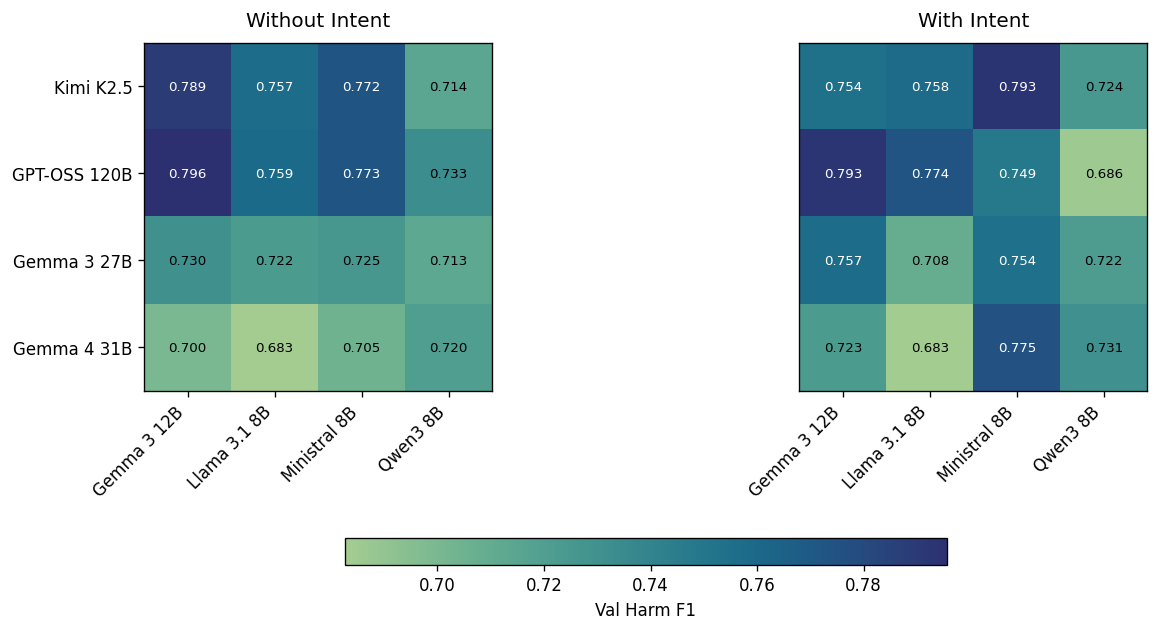

In [8]:
WANDB_ENTITY = "intention-analysis"
WANDB_PROJECT = "Distillation Results"
REFRESH_VAL_F1_CACHE = True  # Set True once to re-fetch val_harm_f1 from W&B; results are cached to disk

_api_summary_index.cache_clear()
load_run_summary.cache_clear()
if REFRESH_VAL_F1_CACHE:
    VAL_F1_CACHE_PATH.unlink(missing_ok=True)
_val_harm_f1_index.cache_clear()

records_df, missing_items = load_combo_rows()

expected_combos = len(TEACHERS) * len(STUDENTS) * len(CONDITIONS)
expected_rows = expected_combos * len(DATASETS)

if records_df.empty:
    raise RuntimeError("No distillation results were found.")

combo_df = (
    records_df.groupby(["teacher_slug", "teacher", "student_slug", "student", "condition_slug", "condition", "run_name", "wandb_source"], as_index=False)
    .agg(
        datasets_loaded=("dataset_slug", "nunique"),
        files_loaded=("jsonl_path", "count"),
        mean_accuracy=("accuracy", "mean"),
        mean_precision=("precision", "mean"),
        mean_recall=("recall", "mean"),
        mean_f1=("f1", "mean"),
        total_rows=("num_rows", "sum"),
        scored_rows=("num_scored", "sum"),
        val_harm_f1=("val_harm_f1", "first"),
        missing_predictions=("missing_predictions", "sum"),
        total_tokens=("wandb_total_tokens", "sum"),
        total_elapsed_s=("wandb_elapsed_s", "sum"),
        wandb_runtime_s=("wandb_runtime_s", "first"),
    )
)
_elapsed_denom = combo_df["total_elapsed_s"].replace(0, np.nan)
combo_df["computed_tokens_per_second"] = combo_df["total_tokens"] / _elapsed_denom

combo_df = combo_df.assign(
    teacher_rank=combo_df["teacher_slug"].map({slug: idx for idx, slug in enumerate(TEACHER_ORDER)}),
    student_rank=combo_df["student_slug"].map({slug: idx for idx, slug in enumerate(STUDENT_ORDER)}),
    condition_rank=combo_df["condition_slug"].map({slug: idx for idx, slug in enumerate(CONDITION_ORDER)}),
).sort_values(["teacher_rank", "student_rank", "condition_rank"]).drop(columns=["teacher_rank", "student_rank", "condition_rank"])

records_df = records_df.assign(
    teacher_rank=records_df["teacher_slug"].map({slug: idx for idx, slug in enumerate(TEACHER_ORDER)}),
    student_rank=records_df["student_slug"].map({slug: idx for idx, slug in enumerate(STUDENT_ORDER)}),
    condition_rank=records_df["condition_slug"].map({slug: idx for idx, slug in enumerate(CONDITION_ORDER)}),
    dataset_rank=records_df["dataset_slug"].map({slug: idx for idx, slug in enumerate(DATASET_ORDER)}),
).sort_values(["teacher_rank", "student_rank", "condition_rank", "dataset_rank"]).drop(columns=["teacher_rank", "student_rank", "condition_rank", "dataset_rank"])

print(f"Loaded {len(combo_df)}/{expected_combos} combinations and {len(records_df)}/{expected_rows} dataset files.")
print(f"WandB source counts: {combo_df['wandb_source'].value_counts(dropna=False).to_dict()}")
if missing_items:
    print("Missing items:")
    for item in missing_items:
        print(f"  - {item}")

combo_display = combo_df[[
    "teacher",
    "student",
    "condition",
    "datasets_loaded",
    "mean_accuracy",
    "mean_precision",
    "mean_recall",
    "mean_f1",
    "total_tokens",
    "total_elapsed_s",
    "computed_tokens_per_second",
    "wandb_runtime_s",
    "wandb_source",
]]

combo_display = combo_display.rename(columns={
    "mean_accuracy": "accuracy",
    "mean_precision": "precision",
    "mean_recall": "recall",
    "mean_f1": "f1",
    "total_tokens": "tokens",
    "total_elapsed_s": "elapsed_s",
    "computed_tokens_per_second": "tok_per_s",
    "wandb_runtime_s": "wandb_runtime_s",
})

for col in ["accuracy", "precision", "recall", "f1", "tokens", "elapsed_s", "tok_per_s", "wandb_runtime_s"]:
    combo_display[col] = pd.to_numeric(combo_display[col], errors="coerce")

display(
    combo_display.style.format({
        "accuracy": "{:.3f}",
        "precision": "{:.3f}",
        "recall": "{:.3f}",
        "f1": "{:.3f}",
        "tokens": "{:.0f}",
        "elapsed_s": "{:.1f}",
        "tok_per_s": "{:.1f}",
        "wandb_runtime_s": "{:.0f}",
    })
)

print("\nDataset-level details (first 12 rows):")
records_preview = records_df[[
    "teacher",
    "student",
    "condition",
    "dataset",
    "accuracy",
    "precision",
    "recall",
    "f1",
    "num_rows",
    "missing_predictions",
    "wandb_elapsed_s",
    "wandb_total_tokens",
    "wandb_tokens_per_second",
]].head(12).copy()

for col in ["accuracy", "precision", "recall", "f1", "wandb_elapsed_s", "wandb_total_tokens", "wandb_tokens_per_second"]:
    records_preview[col] = pd.to_numeric(records_preview[col], errors="coerce")

display(
    records_preview.style.format({
        "accuracy": "{:.3f}",
        "precision": "{:.3f}",
        "recall": "{:.3f}",
        "f1": "{:.3f}",
        "wandb_elapsed_s": "{:.1f}",
        "wandb_total_tokens": "{:.0f}",
        "wandb_tokens_per_second": "{:.1f}",
    })
)

FIGURES_DIR = PROJECT_ROOT / "notebooks" / "distillation" / "figures"
FIGURES_DIR.mkdir(exist_ok=True)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), sharey=True)
axes[1].yaxis.set_visible(False)
axes[2].yaxis.set_visible(False)
heatmap_min = float(combo_df['val_harm_f1'].min())
heatmap_max = float(combo_df['val_harm_f1'].max())
cmap = sns.color_palette("crest", as_cmap=True)
for ax, condition_slug in zip(axes, CONDITION_ORDER):
    pivot = (
        combo_df[combo_df["condition_slug"] == condition_slug]
        .pivot(index="teacher", columns="student", values="val_harm_f1")
        .reindex(index=[TEACHERS[k] for k in TEACHER_ORDER], columns=[STUDENTS[k] for k in STUDENT_ORDER])
    )
    image = ax.imshow(pivot.values, vmin=heatmap_min, vmax=heatmap_max, cmap=cmap)
    ax.set_title(CONDITIONS[condition_slug], pad=10)
    ax.set_xticks(np.arange(len(pivot.columns)), labels=pivot.columns, rotation=45, ha="right")
    ax.set_yticks(np.arange(len(pivot.index)), labels=pivot.index)
    for i in range(pivot.shape[0]):
        for j in range(pivot.shape[1]):
            cell_value = pivot.iloc[i, j]
            norm_val = (cell_value - heatmap_min) / (heatmap_max - heatmap_min + 1e-12)
            text_color = "white" if norm_val > 0.55 else "black"
            ax.text(j, i, f"{cell_value:.3f}", ha="center", va="center", color=text_color, fontsize=8)

fig.subplots_adjust(wspace=0, left=0.11, right=0.97, bottom=0.36, top=0.94)
# Derive colorbar position from actual axes extents so it stays centred
_p0, _p2 = axes[0].get_position(), axes[2].get_position()
_cbar_total_w = _p2.x1 - _p0.x0
_cbar_w = _cbar_total_w * 0.4
_cbar_left = _p0.x0 + (_cbar_total_w - _cbar_w) / 2
cbar_ax = fig.add_axes([_cbar_left, 0.07, _cbar_w, 0.045])
fig.colorbar(image, cax=cbar_ax, orientation="horizontal", label="Val Harm F1")
fig.savefig(FIGURES_DIR / "distillation_heatmap.pdf", bbox_inches="tight")
plt.show()

## Test Harm F1 — Annotated Intents Dataset

This shows the test F1 scores on the annotated intents dataset for each teacher-student-condition combination.
Selection of best adapters is still based on val_harm_f1 from training, but evaluation results are
reported on the human-annotated test set.


In [ ]:
# Extract F1 scores specifically from the annotated_intents dataset
annotated_intents_df = records_df[records_df['dataset_slug'] == 'annotated-intents'].copy()

# Aggregate by teacher, student, condition
test_f1_combo = (
    annotated_intents_df.groupby(
        ['teacher_slug', 'teacher', 'student_slug', 'student', 'condition_slug', 'condition'],
        as_index=False
    )
    .agg(test_f1=('f1', 'first'))
    .sort_values(['teacher_slug', 'student_slug', 'condition_slug'])
)

# Create heatmaps for each condition showing test F1 on annotated intents
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), sharey=True)
axes[1].yaxis.set_visible(False)
axes[2].yaxis.set_visible(False)

# Find min/max for consistent colorbar across conditions
test_f1_min = float(test_f1_combo['test_f1'].min())
test_f1_max = float(test_f1_combo['test_f1'].max())
cmap = sns.color_palette('crest', as_cmap=True)

for ax, condition_slug in zip(axes, CONDITION_ORDER):
    pivot = (
        test_f1_combo[test_f1_combo['condition_slug'] == condition_slug]
        .pivot(index='teacher', columns='student', values='test_f1')
        .reindex(
            index=[TEACHERS[k] for k in TEACHER_ORDER],
            columns=[STUDENTS[k] for k in STUDENT_ORDER]
        )
    )
    image = ax.imshow(pivot.values, vmin=test_f1_min, vmax=test_f1_max, cmap=cmap)
    ax.set_title(CONDITIONS[condition_slug], pad=10)
    ax.set_xticks(np.arange(len(pivot.columns)), labels=pivot.columns, rotation=45, ha='right')
    ax.set_yticks(np.arange(len(pivot.index)), labels=pivot.index)
    for i in range(pivot.shape[0]):
        for j in range(pivot.shape[1]):
            cell_value = pivot.iloc[i, j]
            norm_val = (cell_value - test_f1_min) / (test_f1_max - test_f1_min + 1e-12)
            text_color = 'white' if norm_val > 0.55 else 'black'
            ax.text(j, i, f'{cell_value:.3f}', ha='center', va='center', color=text_color, fontsize=8)

fig.subplots_adjust(wspace=0, left=0.11, right=0.97, bottom=0.36, top=0.94)
_p0, _p2 = axes[0].get_position(), axes[2].get_position()
_cbar_total_w = _p2.x1 - _p0.x0
_cbar_w = _cbar_total_w * 0.4
_cbar_left = _p0.x0 + (_cbar_total_w - _cbar_w) / 2
cbar_ax = fig.add_axes([_cbar_left, 0.07, _cbar_w, 0.045])
fig.colorbar(image, cax=cbar_ax, orientation='horizontal', label='Test Harm F1 (Annotated Intents)')
fig.savefig(FIGURES_DIR / 'distillation_test_f1_heatmap.pdf', bbox_inches='tight')
plt.show()


Average tokens per prompt across all datasets and both conditions:


,teacher,student,total_tokens,total_prompts,total_elapsed_s,avg_tokens_per_prompt,avg_tokens_per_second
12,Kimi K2.5,Gemma 3 12B,4460771,18738,1189.8,238.1,3749.1
13,Kimi K2.5,Llama 3.1 8B,4770333,18738,746.7,254.6,6388.8
14,Kimi K2.5,Ministral 8B,4716849,18738,911.1,251.7,5177.2
15,Kimi K2.5,Qwen3 8B,4480261,18738,732.2,239.1,6119.0
0,GPT-OSS 120B,Gemma 3 12B,2585921,18738,724.2,138.0,3570.8
1,GPT-OSS 120B,Llama 3.1 8B,2695686,18738,417.3,143.9,6459.7
2,GPT-OSS 120B,Ministral 8B,2719018,18738,534.6,145.1,5086.0
3,GPT-OSS 120B,Qwen3 8B,2528216,18738,427.1,134.9,5919.6
4,Gemma 3 27B,Gemma 3 12B,3210416,18738,958.6,171.3,3349.2
5,Gemma 3 27B,Llama 3.1 8B,3258799,18738,540.1,173.9,6034.1


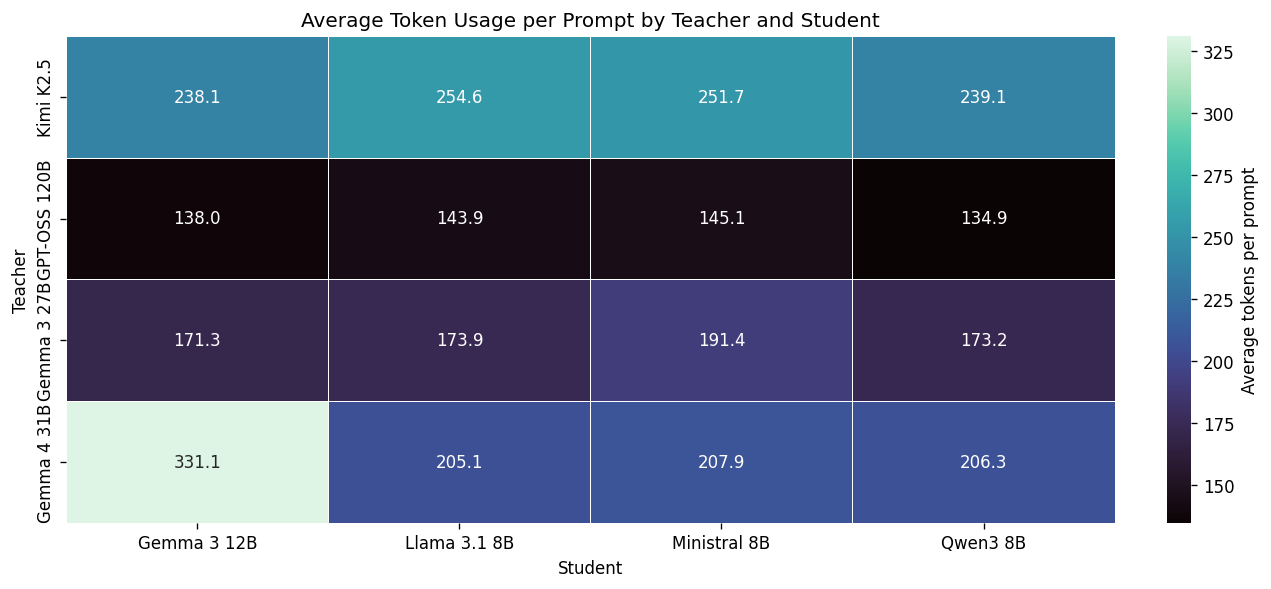


Tokens per second across students (averaged over teachers and intent conditions):


,student,tokens_per_second,total_tokens,total_elapsed_s
0,Gemma 3 12B,2911.0,16462103,5655.1
1,Llama 3.1 8B,6304.1,14568811,2311.0
2,Ministral 8B,4743.3,14919085,3145.3
3,Qwen3 8B,5652.1,14118776,2498.0


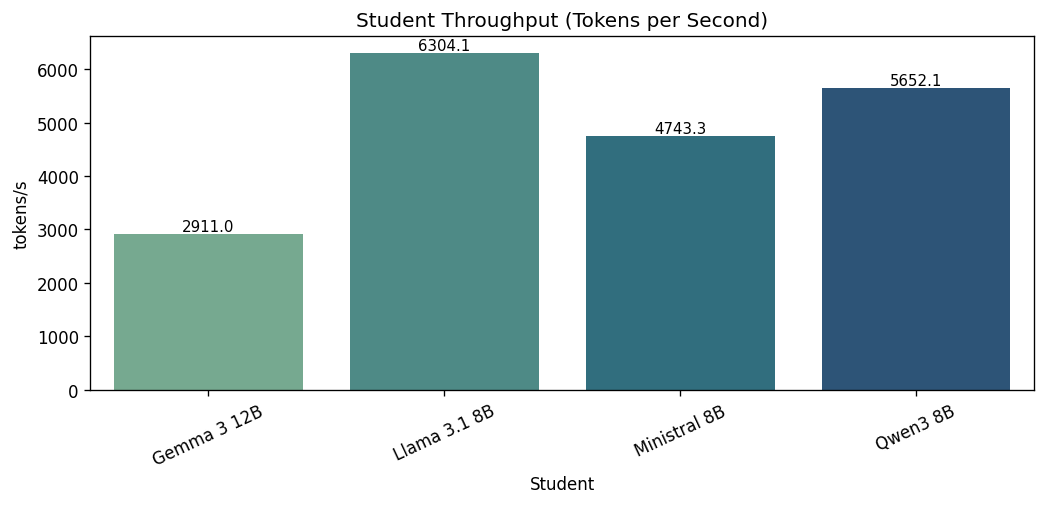


Condition-level token usage (tokens/prompt and tokens/s):


,teacher,student,condition,total_tokens,total_rows,total_elapsed_s,avg_tokens_per_prompt,avg_tokens_per_second
24,GPT-OSS 120B,Gemma 3 12B,With Intent,1378242,9369,402.1,147.1,3427.7
25,GPT-OSS 120B,Gemma 3 12B,Without Intent,1207679,9369,322.1,128.9,3749.4
26,GPT-OSS 120B,Llama 3.1 8B,With Intent,1439227,9369,231.4,153.6,6219.4
27,GPT-OSS 120B,Llama 3.1 8B,Without Intent,1256459,9369,185.9,134.1,6758.9
28,GPT-OSS 120B,Ministral 8B,With Intent,1456258,9369,295.2,155.4,4933.4
29,GPT-OSS 120B,Ministral 8B,Without Intent,1262760,9369,239.4,134.8,5274.0
30,GPT-OSS 120B,Qwen3 8B,With Intent,1357990,9369,238.2,144.9,5701.1
31,GPT-OSS 120B,Qwen3 8B,Without Intent,1170226,9369,188.9,124.9,6195.3
0,Gemma 3 27B,Gemma 3 12B,With Intent,1566411,9369,457.9,167.2,3420.9
1,Gemma 3 27B,Gemma 3 12B,Without Intent,1644005,9369,500.7,175.5,3283.7


In [9]:
# Token usage analysis: average tokens per prompt by teacher and student.

teacher_student_tokens = (
    combo_df.groupby(["teacher", "student"], as_index=False)
    .agg(
        total_tokens=("total_tokens", "sum"),
        total_prompts=("total_rows", "sum"),
        total_elapsed_s=("total_elapsed_s", "sum"),
    )
)
teacher_student_tokens["avg_tokens_per_prompt"] = np.where(
    teacher_student_tokens["total_prompts"] > 0,
    teacher_student_tokens["total_tokens"] / teacher_student_tokens["total_prompts"],
    np.nan,
)
teacher_student_tokens["avg_tokens_per_second"] = np.where(
    teacher_student_tokens["total_elapsed_s"] > 0,
    teacher_student_tokens["total_tokens"] / teacher_student_tokens["total_elapsed_s"],
    np.nan,
)

teacher_student_tokens = teacher_student_tokens.assign(
    teacher_rank=lambda df: df["teacher"].map({name: idx for idx, name in enumerate([TEACHERS[k] for k in TEACHER_ORDER])}),
    student_rank=lambda df: df["student"].map({name: idx for idx, name in enumerate([STUDENTS[k] for k in STUDENT_ORDER])}),
).sort_values(["teacher_rank", "student_rank"]).drop(columns=["teacher_rank", "student_rank"])

print("Average tokens per prompt across all datasets and both conditions:")
display(
    teacher_student_tokens.style.format(
        {
            "total_tokens": "{:.0f}",
            "total_prompts": "{:.0f}",
            "total_elapsed_s": "{:.1f}",
            "avg_tokens_per_prompt": "{:.1f}",
            "avg_tokens_per_second": "{:.1f}",
        }
    )
)

pivot_tokens = teacher_student_tokens.pivot(index="teacher", columns="student", values="avg_tokens_per_prompt")
pivot_tokens = pivot_tokens.reindex(index=[TEACHERS[k] for k in TEACHER_ORDER], columns=[STUDENTS[k] for k in STUDENT_ORDER])

fig, ax = plt.subplots(figsize=(10.5, 4.8), constrained_layout=True)
sns.heatmap(
    pivot_tokens,
    annot=True,
    fmt=".1f",
    cmap="mako",
    linewidths=0.4,
    linecolor="white",
    cbar_kws={"label": "Average tokens per prompt"},
    ax=ax,
)
ax.set_title("Average Token Usage per Prompt by Teacher and Student")
ax.set_xlabel("Student")
ax.set_ylabel("Teacher")
plt.show()

# Student-only throughput summary, averaged across all teachers and both intent conditions.
student_tps = (
    combo_df.groupby("student", as_index=False)
    .agg(total_tokens=("total_tokens", "sum"), total_elapsed_s=("total_elapsed_s", "sum"))
)
student_tps["tokens_per_second"] = np.where(
    student_tps["total_elapsed_s"] > 0,
    student_tps["total_tokens"] / student_tps["total_elapsed_s"],
    np.nan,
)
student_tps = student_tps.assign(
    student_rank=student_tps["student"].map({name: idx for idx, name in enumerate([STUDENTS[k] for k in STUDENT_ORDER])})
).sort_values("student_rank").drop(columns=["student_rank"])

print("\nTokens per second across students (averaged over teachers and intent conditions):")
display(
    student_tps[["student", "tokens_per_second", "total_tokens", "total_elapsed_s"]].style.format(
        {
            "tokens_per_second": "{:.1f}",
            "total_tokens": "{:.0f}",
            "total_elapsed_s": "{:.1f}",
        }
    )
)

fig, ax = plt.subplots(figsize=(8.6, 4.1), constrained_layout=True)
colors = sns.color_palette("crest", n_colors=len(student_tps))
sns.barplot(
    data=student_tps,
    x="student",
    y="tokens_per_second",
    hue="student",
    palette=colors,
    dodge=False,
    legend=False,
    ax=ax,
)
ax.set_title("Student Throughput (Tokens per Second)")
ax.set_xlabel("Student")
ax.set_ylabel("tokens/s")
ax.tick_params(axis="x", rotation=25)
for bar, value in zip(ax.patches, student_tps["tokens_per_second"]):
    ax.text(bar.get_x() + bar.get_width() / 2, value, f"{value:.1f}", ha="center", va="bottom", fontsize=9)
plt.show()

# Optional condition breakdown for the same normalization.
condition_tokens = combo_df[["teacher", "student", "condition", "total_tokens", "total_rows", "total_elapsed_s"]].copy()
condition_tokens["avg_tokens_per_prompt"] = np.where(
    condition_tokens["total_rows"] > 0,
    condition_tokens["total_tokens"] / condition_tokens["total_rows"],
    np.nan,
)
condition_tokens["avg_tokens_per_second"] = np.where(
    condition_tokens["total_elapsed_s"] > 0,
    condition_tokens["total_tokens"] / condition_tokens["total_elapsed_s"],
    np.nan,
)

print("\nCondition-level token usage (tokens/prompt and tokens/s):")
display(
    condition_tokens.sort_values(["teacher", "student", "condition"]).style.format(
        {
            "total_tokens": "{:.0f}",
            "total_rows": "{:.0f}",
            "total_elapsed_s": "{:.1f}",
            "avg_tokens_per_prompt": "{:.1f}",
            "avg_tokens_per_second": "{:.1f}",
        }
    )
)

Paired condition comparison at the teacher/student level (F1):


condition_slug,teacher,student,without_intent,with_intent,intent_delta
12,GPT-OSS 120B,Gemma 3 12B,0.810,0.801,-0.008
13,GPT-OSS 120B,Llama 3.1 8B,0.801,0.803,+0.002
14,GPT-OSS 120B,Ministral 8B,0.795,0.783,-0.012
15,GPT-OSS 120B,Qwen3 8B,0.797,0.785,-0.013
0,Gemma 3 27B,Gemma 3 12B,0.757,0.797,+0.040
1,Gemma 3 27B,Llama 3.1 8B,0.765,0.774,+0.009
2,Gemma 3 27B,Ministral 8B,0.744,0.774,+0.030
3,Gemma 3 27B,Qwen3 8B,0.782,0.780,-0.002
4,Gemma 4 31B,Gemma 3 12B,0.746,0.765,+0.019
5,Gemma 4 31B,Llama 3.1 8B,0.773,0.767,-0.006


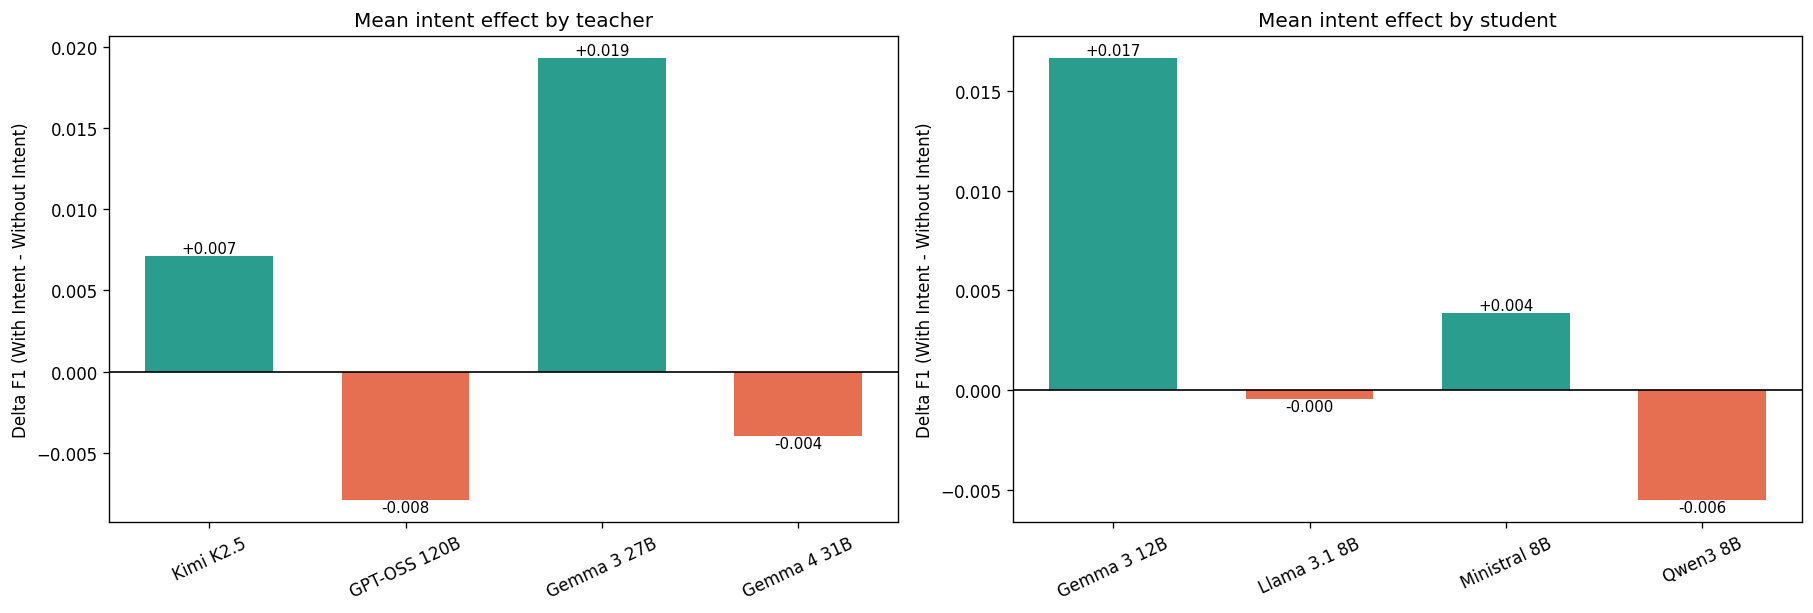

Summary of the intent effect:
  Mean delta across teacher/student pairs: +0.0036
  Pairs with positive delta: 8/16


In [10]:
# Compare the intent condition as a paired delta: With Intent - Without Intent.
condition_f1 = (
    combo_df.pivot_table(
        index=["teacher_slug", "teacher", "student_slug", "student"],
        columns="condition_slug",
        values="mean_f1",
        aggfunc="mean",
    )
    .reset_index()
)

# For three conditions, we can compute pairwise deltas
condition_f1["synthetic_vs_no_intent"] = condition_f1["synthetic_intent"] - condition_f1["no_intent"]
condition_f1["human_vs_synthetic_intent"] = condition_f1["human_intent"] - condition_f1["synthetic_intent"]
condition_f1["human_vs_no_intent"] = condition_f1["human_intent"] - condition_f1["no_intent"]

pairwise_display = condition_f1[[
    "teacher",
    "student",
    "no_intent",
    "human_intent",
    "intent_delta",
]].copy()

teacher_effect = (
    condition_f1.groupby(["teacher_slug", "teacher"], as_index=False)
    .agg(
        mean_delta=("intent_delta", "mean"),
        std_delta=("intent_delta", "std"),
        mean_without=("no_intent", "mean"),
        mean_with=("with_intent", "mean"),
    )
    .assign(teacher_rank=lambda df: df["teacher_slug"].map({slug: idx for idx, slug in enumerate(TEACHER_ORDER)}))
    .sort_values("teacher_rank")
    .drop(columns="teacher_rank")
)

student_effect = (
    condition_f1.groupby(["student_slug", "student"], as_index=False)
    .agg(
        mean_delta=("intent_delta", "mean"),
        std_delta=("intent_delta", "std"),
        mean_without=("no_intent", "mean"),
        mean_with=("with_intent", "mean"),
    )
    .assign(student_rank=lambda df: df["student_slug"].map({slug: idx for idx, slug in enumerate(STUDENT_ORDER)}))
    .sort_values("student_rank")
    .drop(columns="student_rank")
)

print("Paired condition comparison at the teacher/student level (F1):")
display(
    pairwise_display.sort_values(["teacher", "student"]).style.format({
        "no_intent": "{:.3f}",
        "human_intent": "{:.3f}",
        "intent_delta": "{:+.3f}",
    })
)

fig, axes = plt.subplots(1, 2, figsize=(15, 5), constrained_layout=True)

for axis, effect_df, label, order_key in [
    (axes[0], teacher_effect, "teacher", "teacher"),
    (axes[1], student_effect, "student", "student"),
]:
    colors = ["#2A9D8F" if value >= 0 else "#E76F51" for value in effect_df["mean_delta"]]
    axis.bar(effect_df[label], effect_df["mean_delta"], color=colors, width=0.65)
    axis.axhline(0, color="black", linewidth=1)
    axis.set_title(f"Mean intent effect by {label}")
    axis.set_ylabel("Delta F1 (With Intent - Without Intent)")
    axis.tick_params(axis="x", rotation=25)
    for x_pos, value in enumerate(effect_df["mean_delta"]):
        axis.text(x_pos, value, f"{value:+.3f}", ha="center", va="bottom" if value >= 0 else "top", fontsize=9)

plt.show()

print("Summary of the intent effect:")
print(
    f"  Mean delta across teacher/student pairs: {condition_f1['intent_delta'].mean():+.4f}"
)
print(
    f"  Pairs with positive delta: {(condition_f1['intent_delta'] > 0).sum()}/{len(condition_f1)}"
)


condition_slug,dataset,without_intent,with_intent,intent_delta
2,Toxic Chat,0.612,0.640,+0.028
3,WildGuardMix,0.845,0.849,+0.003
0,Aegis,0.801,0.801,+0.000
4,XSTest,0.895,0.891,-0.004
1,Annotated Intents,0.695,0.686,-0.009


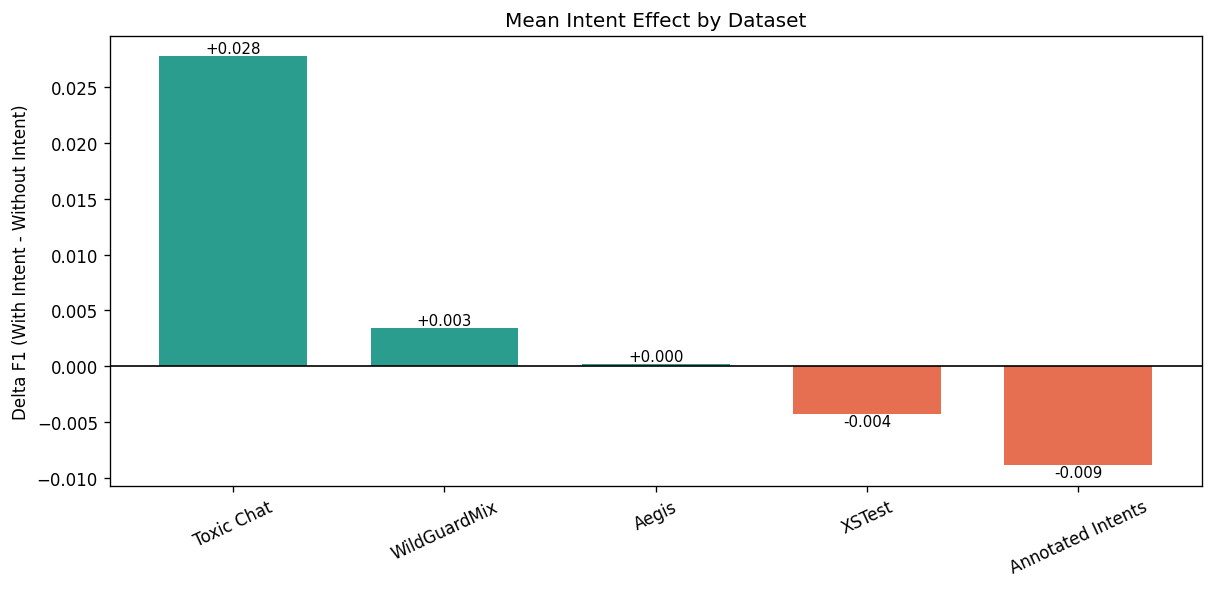

Dataset-level intent effect summary:
  Mean delta across datasets: +0.0036
  Datasets with positive delta: 3/5

Best and worst datasets by intent delta:


condition_slug,dataset,without_intent,with_intent,intent_delta,rank
0,Toxic Chat,0.612,0.640,+0.028,top
1,WildGuardMix,0.845,0.849,+0.003,top
2,Aegis,0.801,0.801,+0.000,top
3,Annotated Intents,0.695,0.686,-0.009,bottom
4,XSTest,0.895,0.891,-0.004,bottom
5,Aegis,0.801,0.801,+0.000,bottom


In [11]:
dataset_f1 = (
    records_df.pivot_table(
        index=["dataset_slug", "dataset"],
        columns="condition_slug",
        values="f1",
        aggfunc="mean",
    )
    .reset_index()
)

dataset_f1["synthetic_vs_no_intent"] = dataset_f1["synthetic_intent"] - dataset_f1["no_intent"]
dataset_f1["human_vs_synthetic_intent"] = dataset_f1["human_intent"] - dataset_f1["synthetic_intent"]
dataset_f1["human_vs_no_intent"] = dataset_f1["human_intent"] - dataset_f1["no_intent"]

dataset_display = dataset_f1[[
    "dataset",
    "no_intent",
    "synthetic_intent",
    "human_intent",
    "synthetic_vs_no_intent",
    "human_vs_synthetic_intent",
    "human_vs_no_intent",
]].copy()

dataset_display = dataset_display.sort_values("intent_delta", ascending=False)

display(
    dataset_display.style.format({
        "no_intent": "{:.3f}",
        "human_intent": "{:.3f}",
        "intent_delta": "{:+.3f}",
    })
)

fig, ax = plt.subplots(figsize=(10, 4.8), constrained_layout=True)
colors = ["#2A9D8F" if value >= 0 else "#E76F51" for value in dataset_display["intent_delta"]]
ax.bar(dataset_display["dataset"], dataset_display["intent_delta"], color=colors, width=0.7)
ax.axhline(0, color="black", linewidth=1)
ax.set_title("Mean Intent Effect by Dataset")
ax.set_ylabel("Delta F1 (With Intent - Without Intent)")
ax.tick_params(axis="x", rotation=25)
for x_pos, value in enumerate(dataset_display["intent_delta"]):
    ax.text(x_pos, value, f"{value:+.3f}", ha="center", va="bottom" if value >= 0 else "top", fontsize=9)
plt.show()

print("Dataset-level intent effect summary:")
print(f"  Mean delta across datasets: {dataset_f1['intent_delta'].mean():+.4f}")
print(f"  Datasets with positive delta: {(dataset_f1['intent_delta'] > 0).sum()}/{len(dataset_f1)}")

print("\nBest and worst datasets by intent delta:")
display(
    pd.concat(
        [
            dataset_display.head(3).assign(rank="top"),
            dataset_display.tail(3).sort_values("intent_delta").assign(rank="bottom"),
        ],
        ignore_index=True,
    ).style.format({
        "no_intent": "{:.3f}",
        "human_intent": "{:.3f}",
        "intent_delta": "{:+.3f}",
    })
)


,Best distillation,WildGuard
Average,0.829,0.823
Aegis,0.828,0.809
Toxic Chat,0.678,0.651
WildGuardMix,0.874,0.887
XSTest,0.938,0.945


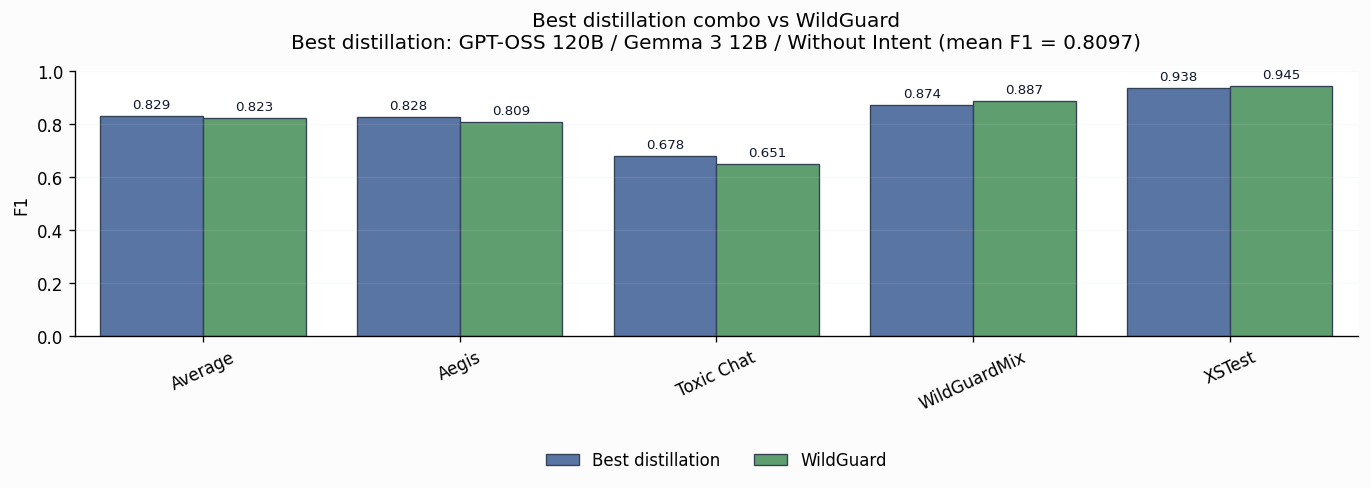

Best combo selected programmatically: teacher=GPT-OSS 120B, student=Gemma 3 12B, condition=Without Intent, mean_f1=0.8097
Distillation average across datasets: 0.8295
WildGuard average across datasets: 0.8232


In [12]:
# Best overall result: compare the top distillation combo against WildGuard across datasets.

def load_jsonl(path: Path) -> list[dict]:
    rows = []
    with open(path) as handle:
        for line in handle:
            line = line.strip()
            if line:
                rows.append(json.loads(line))
    return rows


def compute_metrics(results: list[dict]) -> dict:
    tp = fp = tn = fn = 0
    for record in results:
        true_harm = record.get("true_harm_binary") or record.get("true_harm")
        pred_harm = record.get("predicted_harm")
        if true_harm is None or pred_harm is None:
            continue
        true_lower = str(true_harm).lower()
        pred_lower = str(pred_harm).lower()
        if true_lower == "harmful" and pred_lower == "harmful":
            tp += 1
        elif true_lower == "safe" and pred_lower == "harmful":
            fp += 1
        elif true_lower == "safe" and pred_lower == "safe":
            tn += 1
        elif true_lower == "harmful" and pred_lower == "safe":
            fn += 1
    total = tp + fp + tn + fn
    precision = tp / (tp + fp) if (tp + fp) else 0.0
    recall = tp / (tp + fn) if (tp + fn) else 0.0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) else 0.0
    return {"accuracy": (tp + tn) / total if total else 0.0, "precision": precision, "recall": recall, "f1": f1}


best_combo = combo_df.sort_values("val_harm_f1", ascending=False).iloc[0]
best_teacher = best_combo["teacher"]
best_student = best_combo["student"]
best_condition = best_combo["condition"]
best_score = float(best_combo["mean_f1"])

best_records = records_df[
    (records_df["teacher"] == best_teacher)
    & (records_df["student"] == best_student)
    & (records_df["condition"] == best_condition)
].copy()

best_summary = (
    best_records.groupby("dataset", as_index=False)["f1"]
    .mean()
    .rename(columns={"dataset": "dataset", "f1": "f1"})
    .query("dataset != 'Annotated Intents'")
    .sort_values("dataset")
    .reset_index(drop=True)
)

safety_results_root = PROJECT_ROOT / "data/safety_experiment"
wildguard_paths = {
    "Aegis": safety_results_root / "aegis" / "allenai_wildguard_wildguard_classification.jsonl",
    "Toxic Chat": safety_results_root / "toxic-chat" / "allenai_wildguard_wildguard_classification.jsonl",
    "WildGuardMix": safety_results_root / "wildguardmix" / "allenai_wildguard_wildguard_classification.jsonl",
    "XSTest": safety_results_root / "xstest" / "allenai_wildguard_wildguard_classification.jsonl",
}

wildguard_rows = []
for dataset, path in wildguard_paths.items():
    wildguard_rows.append({"dataset": dataset, "model": "WildGuard", **compute_metrics(load_jsonl(path))})

wildguard_summary = pd.DataFrame(wildguard_rows)[["dataset", "model", "f1"]]

comparison_df = pd.concat(
    [
        best_summary.assign(model="Best distillation"),
        wildguard_summary,
    ],
    ignore_index=True,
 )

average_df = comparison_df.groupby("model", as_index=False)["f1"].mean().assign(dataset="Average")
comparison_df = pd.concat([comparison_df, average_df], ignore_index=True)

dataset_order = ["Average"] + sorted(d for d in comparison_df["dataset"].unique() if d != "Average")
model_order = ["Best distillation", "WildGuard"]
comparison_df["dataset"] = pd.Categorical(comparison_df["dataset"], categories=dataset_order, ordered=True)
comparison_df["model"] = pd.Categorical(comparison_df["model"], categories=model_order, ordered=True)
comparison_df = comparison_df.sort_values(["dataset", "model"]).reset_index(drop=True)

display(comparison_df.pivot(index="dataset", columns="model", values="f1").reindex(dataset_order).rename_axis(index=None, columns=None).style.format("{:.3f}"))

fig, ax = plt.subplots(figsize=(13.8, 5.8))
fig.patch.set_facecolor("#fcfcfc")
ax.set_facecolor("white")
palette = {"Best distillation": sns.color_palette("deep")[0], "WildGuard": sns.color_palette("deep")[2]}

sns.barplot(
    data=comparison_df,
    x="dataset",
    y="f1",
    hue="model",
    order=dataset_order,
    hue_order=model_order,
    palette=palette,
    ax=ax,
    edgecolor="#334155",
    linewidth=0.8,
    errorbar=None,
)

ax.set_title(
    f"Best distillation combo vs WildGuard\n"
    f"Best distillation: {best_teacher} / {best_student} / {best_condition} (mean F1 = {best_score:.4f})",
    pad=14,
)
ax.set_xlabel("")
ax.xaxis.label.set_visible(False)
ax.set_ylabel("F1")
ax.set_ylim(0, min(1.0, max(comparison_df["f1"].max() * 1.12, 0.05)))
ax.tick_params(axis="x", rotation=25, labelsize=10)
ax.grid(axis="y", color="#cbd5e1", alpha=0.12, linewidth=0.8)

for container in ax.containers:
    ax.bar_label(container, labels=[f"{bar.get_height():.3f}" for bar in container], padding=3, fontsize=8, color="#0f172a")

ax.legend(title=None, loc="upper center", bbox_to_anchor=(0.5, -0.38), ncol=2, frameon=False)
sns.despine(ax=ax, left=False, bottom=False)
fig.subplots_adjust(bottom=0.50)
plt.show()

print(f"Best combo selected programmatically: teacher={best_teacher}, student={best_student}, condition={best_condition}, mean_f1={best_score:.4f}")
print(f"Distillation average across datasets: {comparison_df[comparison_df['model'] == 'Best distillation']['f1'].mean():.4f}")
print(f"WildGuard average across datasets: {comparison_df[comparison_df['model'] == 'WildGuard']['f1'].mean():.4f}")


Efficiency comparison on overlapping datasets: aegis, annotated-intents, toxic-chat, wildguardmix, xstest
WildGuard metrics source: artifact:intention-analysis/Baselines/safety-experiment-baselines:latest (run=xbo6h3xq)


,model,details,datasets_compared,total_prompts,total_tokens,total_elapsed_s,tokens_per_prompt,seconds_per_prompt,tokens_per_second
0,Best distillation,GPT-OSS 120B / Gemma 3 12B / Without Intent,5,9369,1207679,322.1,128.9,0.0344,3749.4
1,WildGuard,condition=wildguard_classification,5,9367,216072,53.8,23.1,0.0057,4014.7


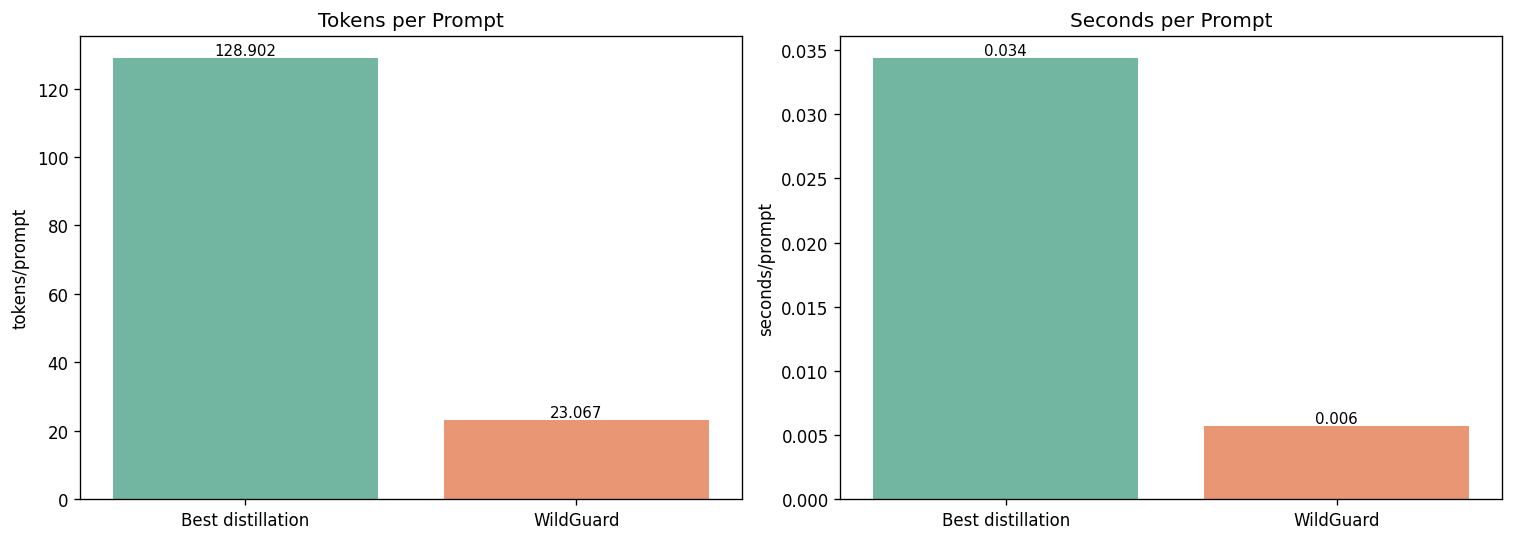

In [13]:
# Efficiency comparison: WildGuard baseline vs best distillation combo

api = wandb.Api()


def _dataset_aliases(slug: str) -> set[str]:
    aliases = {slug, slug.replace("-", "_")}
    if slug == "annotated-intents":
        aliases.add("annotated_intents")
    if slug == "toxic-chat":
        aliases.add("toxic_chat")
    return aliases


def _extract_dataset_condition_metrics(summary: dict) -> pd.DataFrame:
    rows = []
    patterns = [
        re.compile(r"^([^/]+)/([^/]+)/total_tokens$"),
        re.compile(r"^([^/]+)/([^/]+)/elapsed_s$"),
        re.compile(r"^([^/]+)/([^/]+)/total$"),
    ]

    grouped = {}
    for key, value in summary.items():
        if not isinstance(key, str):
            continue
        for pattern in patterns:
            match = pattern.match(key)
            if not match:
                continue
            dataset_raw, condition = match.group(1), match.group(2)
            metric_name = key.rsplit("/", 1)[-1]
            grouped.setdefault((dataset_raw, condition), {})[metric_name] = value
            break

    canonical = {}
    alias_to_canonical = {}
    for dataset_slug in DATASETS.keys():
        for alias in _dataset_aliases(dataset_slug):
            alias_to_canonical[alias] = dataset_slug

    for (dataset_raw, condition), metrics in grouped.items():
        dataset_slug = alias_to_canonical.get(dataset_raw)
        if dataset_slug is None:
            continue
        canonical.setdefault((dataset_slug, condition), {}).update(metrics)

    for (dataset_slug, condition), metrics in canonical.items():
        rows.append(
            {
                "dataset_slug": dataset_slug,
                "condition": condition,
                "total_tokens": pd.to_numeric(metrics.get("total_tokens"), errors="coerce"),
                "elapsed_s": pd.to_numeric(metrics.get("elapsed_s"), errors="coerce"),
                "total_prompts": pd.to_numeric(metrics.get("total"), errors="coerce"),
            }
        )

    return pd.DataFrame(rows)


def _get_wildguard_summary_from_artifact() -> tuple[dict, str]:
    artifact_candidates = [
        "intention-analysis/Baselines/safety-experiment-baselines:latest",
        "Jazhyc/Baselines/safety-experiment-baselines:latest",
    ]

    for artifact_ref in artifact_candidates:
        try:
            artifact = api.artifact(artifact_ref)
            run = artifact.logged_by()
            if run is not None:
                return dict(run.summary), f"artifact:{artifact_ref} (run={run.id})"
        except Exception:
            continue

    run_candidates = [
        "intention-analysis/Baselines",
        "Jazhyc/Baselines",
    ]
    for path in run_candidates:
        try:
            runs = api.runs(path=path, per_page=200)
        except Exception:
            continue

        for run in runs:
            summary = dict(run.summary)
            has_tokens = any(isinstance(k, str) and k.endswith("/total_tokens") for k in summary.keys())
            has_wildguard = (
                "wildguard" in (getattr(run, "display_name", "") or "").lower()
                or "wildguard" in (getattr(run, "name", "") or "").lower()
                or any("wildguard" in str(k).lower() for k in summary.keys())
            )
            if has_tokens and has_wildguard:
                return summary, f"run:{path}/{run.id}"

    raise RuntimeError("Could not locate WildGuard baseline summary in artifacts or Baselines runs.")


# 1) Best distillation aggregate from existing combo_df
best_combo_row = combo_df.sort_values("val_harm_f1", ascending=False).iloc[0]
best_teacher_name = best_combo_row["teacher"]
best_student_name = best_combo_row["student"]
best_condition_name = best_combo_row["condition"]

best_records_eff = records_df[
    (records_df["teacher"] == best_teacher_name)
    & (records_df["student"] == best_student_name)
    & (records_df["condition"] == best_condition_name)
].copy()

# 2) WildGuard metrics from WandB artifact/run summary
wildguard_summary, wildguard_source = _get_wildguard_summary_from_artifact()
wildguard_metrics = _extract_dataset_condition_metrics(wildguard_summary)

if wildguard_metrics.empty:
    raise RuntimeError("Found WildGuard summary source but no dataset-level token/elapsed metrics were parseable.")

# Prefer a condition containing 'wildguard'; otherwise use condition with max dataset coverage.
coverage = (
    wildguard_metrics.groupby("condition", as_index=False)
    .agg(datasets=("dataset_slug", "nunique"))
    .sort_values(["datasets", "condition"], ascending=[False, True])
)
preferred = coverage[coverage["condition"].str.contains("wildguard", case=False, regex=False)]
if not preferred.empty:
    wildguard_condition = preferred.iloc[0]["condition"]
else:
    wildguard_condition = coverage.iloc[0]["condition"]

wildguard_selected = wildguard_metrics[wildguard_metrics["condition"] == wildguard_condition].copy()

# Compare on overlapping datasets for fairness.
common_datasets = sorted(set(best_records_eff["dataset_slug"]).intersection(set(wildguard_selected["dataset_slug"])))
if not common_datasets:
    raise RuntimeError("No overlapping datasets found between best distillation records and WildGuard summary metrics.")

best_overlap = best_records_eff[best_records_eff["dataset_slug"].isin(common_datasets)].copy()
wildguard_overlap = wildguard_selected[wildguard_selected["dataset_slug"].isin(common_datasets)].copy()

best_total_tokens = pd.to_numeric(best_overlap["wandb_total_tokens"], errors="coerce").sum()
best_total_elapsed = pd.to_numeric(best_overlap["wandb_elapsed_s"], errors="coerce").sum()
best_total_prompts = pd.to_numeric(best_overlap["num_rows"], errors="coerce").sum()

wg_total_tokens = pd.to_numeric(wildguard_overlap["total_tokens"], errors="coerce").sum()
wg_total_elapsed = pd.to_numeric(wildguard_overlap["elapsed_s"], errors="coerce").sum()
wg_total_prompts = pd.to_numeric(wildguard_overlap["total_prompts"], errors="coerce").sum()

comparison_efficiency = pd.DataFrame(
    [
        {
            "model": "Best distillation",
            "details": f"{best_teacher_name} / {best_student_name} / {best_condition_name}",
            "datasets_compared": len(common_datasets),
            "total_prompts": best_total_prompts,
            "total_tokens": best_total_tokens,
            "total_elapsed_s": best_total_elapsed,
        },
        {
            "model": "WildGuard",
            "details": f"condition={wildguard_condition}",
            "datasets_compared": len(common_datasets),
            "total_prompts": wg_total_prompts,
            "total_tokens": wg_total_tokens,
            "total_elapsed_s": wg_total_elapsed,
        },
    ]
)

comparison_efficiency["tokens_per_prompt"] = comparison_efficiency["total_tokens"] / comparison_efficiency["total_prompts"]
comparison_efficiency["seconds_per_prompt"] = comparison_efficiency["total_elapsed_s"] / comparison_efficiency["total_prompts"]
comparison_efficiency["tokens_per_second"] = comparison_efficiency["total_tokens"] / comparison_efficiency["total_elapsed_s"]

print("Efficiency comparison on overlapping datasets:", ", ".join(common_datasets))
print("WildGuard metrics source:", wildguard_source)

display(
    comparison_efficiency.style.format(
        {
            "datasets_compared": "{:.0f}",
            "total_prompts": "{:.0f}",
            "total_tokens": "{:.0f}",
            "total_elapsed_s": "{:.1f}",
            "tokens_per_prompt": "{:.1f}",
            "seconds_per_prompt": "{:.4f}",
            "tokens_per_second": "{:.1f}",
        }
    )
)

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.4), constrained_layout=True)
sns.barplot(data=comparison_efficiency, x="model", y="tokens_per_prompt", hue="model", legend=False, ax=axes[0], palette="Set2")
axes[0].set_title("Tokens per Prompt")
axes[0].set_ylabel("tokens/prompt")
axes[0].set_xlabel("")

sns.barplot(data=comparison_efficiency, x="model", y="seconds_per_prompt", hue="model", legend=False, ax=axes[1], palette="Set2")
axes[1].set_title("Seconds per Prompt")
axes[1].set_ylabel("seconds/prompt")
axes[1].set_xlabel("")

for ax in axes:
    for bar in ax.patches:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, h, f"{h:.3f}", ha="center", va="bottom", fontsize=9)

plt.show()